# AI Impact On Jobs

## Project Objective and Overview

This project aims to explore and understand the impact of Artificial Intelligence (AI) on various job roles by analyzing a dataset that contains information about job titles, salaries, experience, education levels, AI exposure, and automation probability. We will perform the following steps:

1.  **Data Loading and Initial Exploration:** Load the dataset and conduct an initial examination to understand its structure, identify missing values, and check data types.
2.  **Exploratory Data Analysis (EDA):** Visualize key relationships and distributions within the data, focusing on factors influencing automation probability and risk categories.
3.  **Predictive Modeling:** Build and evaluate a machine learning model to predict the risk category of jobs based on the available features.

# 01. Business Questions

This analysis aims to answer the following key questions:

- Which job roles are most and least susceptible to automation by 2030?
- How does AI exposure relate to automation probability?
- Do salary, education level, and years of experience influence automation risk?
- Which skills are most prevalent in low-risk versus high-risk jobs?
- Can we build a reliable model to predict a job's automation risk category?

# Importing

Import library


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


#Import CSV And convert to DataFrame

In [ ]:
import pandas as pd

df = pd.read_csv('AI_Impact_on_Jobs_2030.csv')

# 02. Data Overview

Description of the key variables in the dataset:

* **Job_Title:** The title of the job role being analyzed.
* **Education_Level:** Highest level of education required for the role.
* **Years_Experience:** Number of years of experience associated with the role.
* **Average_Salary:** Average annual salary for the role (in USD).
* **AI_Exposure_Index:** A numeric index indicating the degree to which the role is exposed to AI tools and automation.
* **Tech_Growth_Factor:** A measure of how fast the technology sector related to the role is growing.
* **Automation_Probability_2030:** Estimated probability (0–1) that the role will be automated by 2030.
* **Risk_Category:** Classification of the job into Low, Medium, or High automation risk.
* **Skill_1 to Skill_10:** Numeric scores representing the strength of various skills associated with the role.

In [ ]:
df.head()

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


In [ ]:
df.tail()

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
2995,Doctor,111319,6,Bachelor's,0.24,1.18,0.20,Low,0.73,0.37,0.99,0.07,0.08,0.92,0.65,0.33,0.76,0.45
2996,UX Researcher,44363,29,PhD,0.65,0.74,0.35,Medium,0.23,0.48,0.05,0.88,0.56,0.29,0.69,0.80,0.61,0.20
2997,Data Scientist,61325,23,Master's,0.64,0.94,0.39,Medium,0.28,0.62,0.73,0.21,0.96,0.01,0.70,0.29,0.48,0.57
2998,Graphic Designer,110296,7,PhD,0.95,1.23,0.46,Medium,0.21,0.18,0.14,0.22,0.55,0.68,0.31,0.55,0.34,0.70
2999,Graphic Designer,123909,25,PhD,0.69,0.56,0.49,Medium,0.77,0.54,0.95,0.05,0.29,0.22,0.77,0.52,0.14,0.29


In [ ]:
df.shape

(3000, 18)

In [ ]:
df.columns

Index(['Job_Title', 'Average_Salary', 'Years_Experience', 'Education_Level',
       'AI_Exposure_Index', 'Tech_Growth_Factor',
       'Automation_Probability_2030', 'Risk_Category', 'Skill_1', 'Skill_2',
       'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8',
       'Skill_9', 'Skill_10'],
      dtype='object')

In [ ]:
df.dtypes

,0
Job_Title,object
Average_Salary,int64
Years_Experience,int64
Education_Level,object
AI_Exposure_Index,float64
Tech_Growth_Factor,float64
Automation_Probability_2030,float64
Risk_Category,object
Skill_1,float64
Skill_2,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float64
 13  Skill_6           

In [ ]:
df.isnull().sum()

,0
Job_Title,0
Average_Salary,0
Years_Experience,0
Education_Level,0
AI_Exposure_Index,0
Tech_Growth_Factor,0
Automation_Probability_2030,0
Risk_Category,0
Skill_1,0
Skill_2,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,89372.279000,14.677667,0.501283,0.995343,0.501503,0.496973,0.497233,0.499313,0.503667,0.490270,0.499807,0.499160,0.502843,0.501433,0.493627
std,34608.088767,8.739788,0.284004,0.287669,0.247881,0.287888,0.288085,0.288354,0.287063,0.285818,0.286050,0.288044,0.289832,0.285818,0.286464
min,30030.000000,0.000000,0.000000,0.500000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58640.000000,7.000000,0.260000,0.740000,0.310000,0.240000,0.250000,0.250000,0.260000,0.240000,0.260000,0.250000,0.250000,0.260000,0.250000
50%,89318.000000,15.000000,0.500000,1.000000,0.500000,0.505000,0.500000,0.500000,0.510000,0.490000,0.500000,0.490000,0.500000,0.500000,0.490000
75%,119086.500000,22.000000,0.740000,1.240000,0.700000,0.740000,0.740000,0.750000,0.750000,0.730000,0.740000,0.750000,0.750000,0.740000,0.740000
max,149798.000000,29.000000,1.000000,1.500000,0.950000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 03. Exploratory Data Analysis (EDA)

In [ ]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

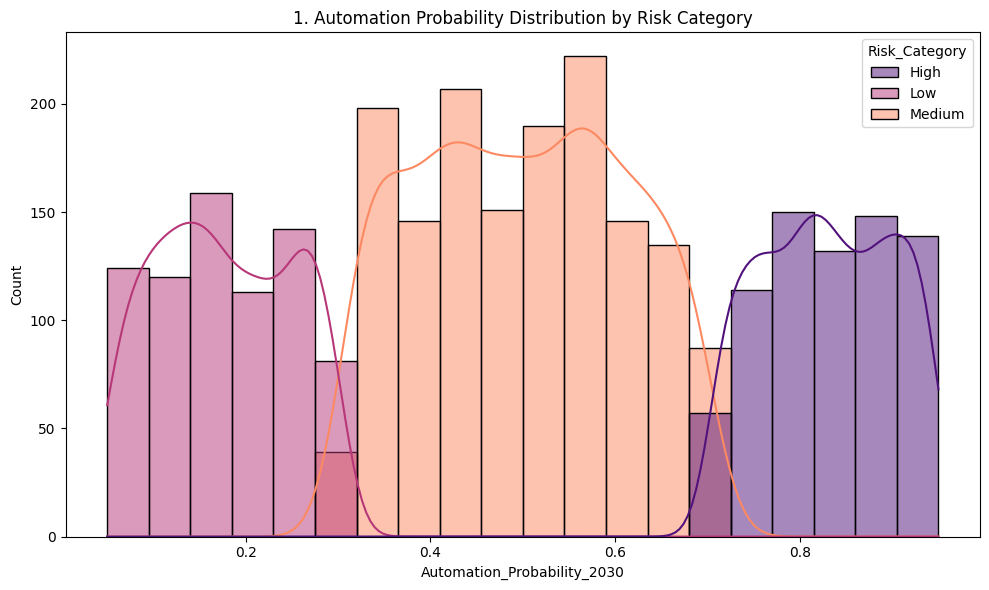

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Automation_Probability_2030', hue='Risk_Category', bins=20, kde=True, palette='magma')
plt.title(f'{plot_no}. Automation Probability Distribution by Risk Category')
show_fig()
plot_no += 1

### Conclusion for Plot 1: Automation Probability Distribution by Risk Category
This histogram shows the distribution of automation probability for each risk category. High-risk jobs tend to have a higher automation probability, while low-risk jobs cluster at lower probabilities.

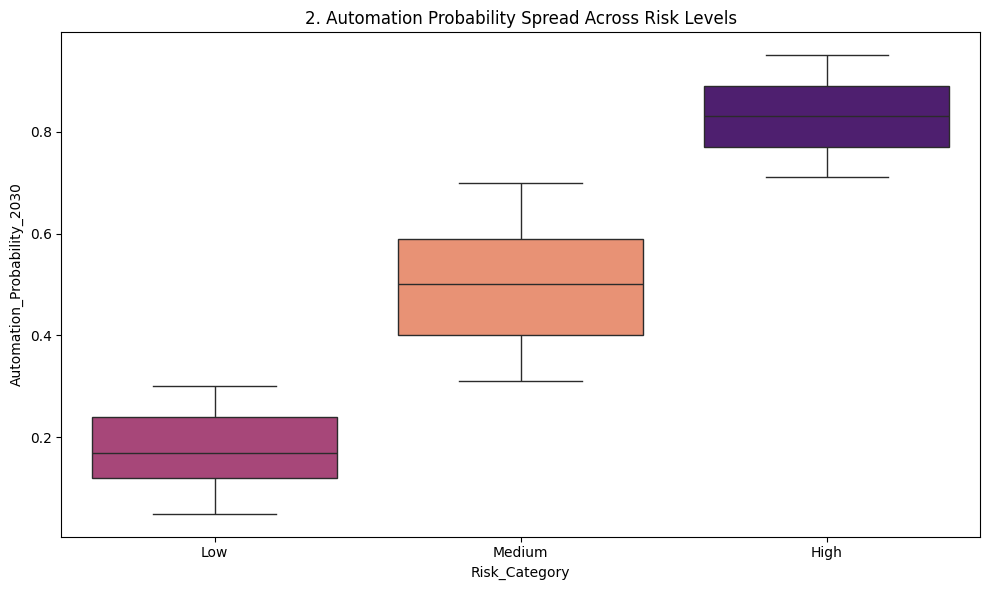

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Risk_Category', y='Automation_Probability_2030', order=['Low', 'Medium', 'High'], hue='Risk_Category', legend=False, palette='magma')
plt.title(f'{plot_no}. Automation Probability Spread Across Risk Levels')
show_fig()
plot_no += 1

### Conclusion for Plot 2: Automation Probability Spread Across Risk Levels
The box plot clearly indicates that jobs categorized as 'High' risk have significantly higher automation probabilities compared to 'Medium' and 'Low' risk categories, with 'Low' risk jobs having the lowest probabilities.

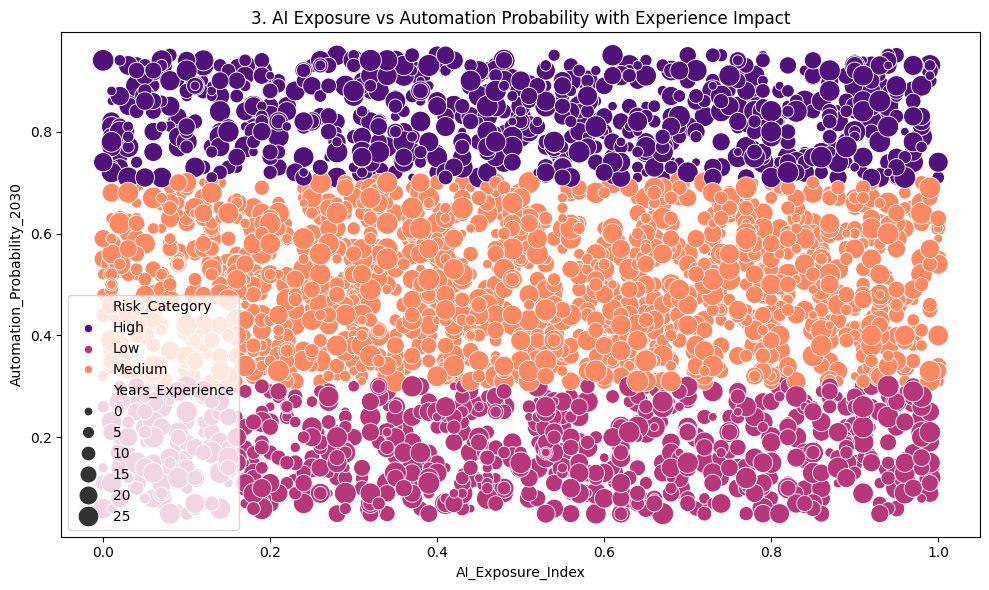

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='AI_Exposure_Index', y='Automation_Probability_2030', hue='Risk_Category', size='Years_Experience', sizes=(40, 250), palette='magma')
plt.title(f'{plot_no}. AI Exposure vs Automation Probability with Experience Impact')
show_fig()
plot_no += 1

### Conclusion for Plot 3: AI Exposure vs Automation Probability with Experience Impact
There is a general trend where a higher AI Exposure Index correlates with a higher Automation Probability. Jobs with more years of experience (larger points) are distributed across all risk categories, but generally, higher experience does not directly protect against automation if AI exposure is high.

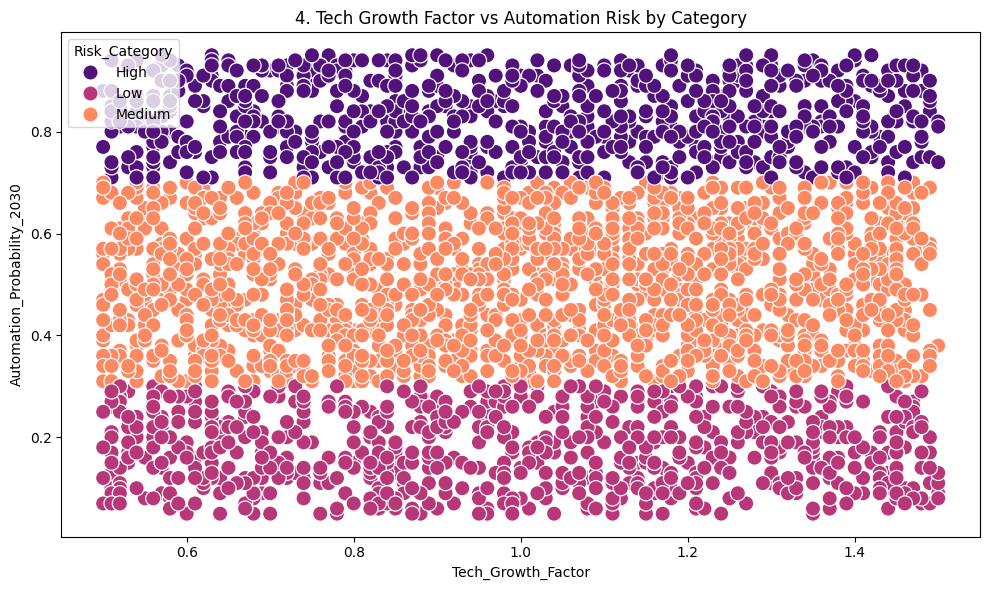

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Tech_Growth_Factor', y='Automation_Probability_2030', hue='Risk_Category', s=120, palette='magma')
plt.title(f'{plot_no}. Tech Growth Factor vs Automation Risk by Category')
show_fig()
plot_no += 1

### Conclusion for Plot 4: Tech Growth Factor vs Automation Risk by Category
The scatter plot reveals no strong linear correlation between Tech Growth Factor and Automation Probability across all risk categories. However, high automation probability jobs (especially in the 'High' risk category) are found across a wide range of tech growth factors.

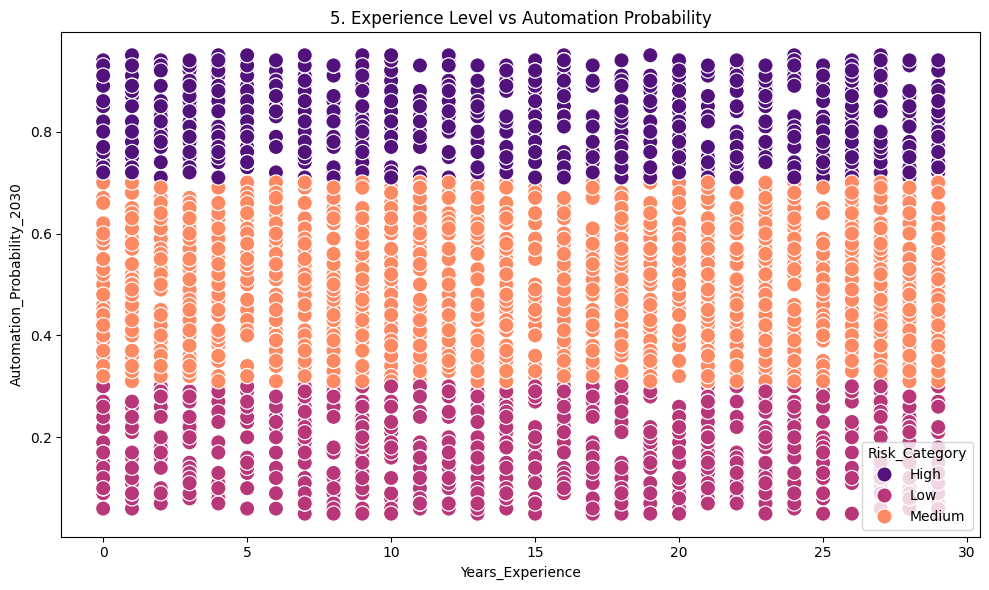

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Years_Experience', y='Automation_Probability_2030', hue='Risk_Category', s=120, palette='magma')
plt.title(f'{plot_no}. Experience Level vs Automation Probability')
show_fig()
plot_no += 1

### Conclusion for Plot 5: Experience Level vs Automation Probability
This plot suggests that years of experience alone do not consistently predict automation probability. Jobs in all risk categories are spread across the experience spectrum, indicating that other factors are more influential in determining automation risk.

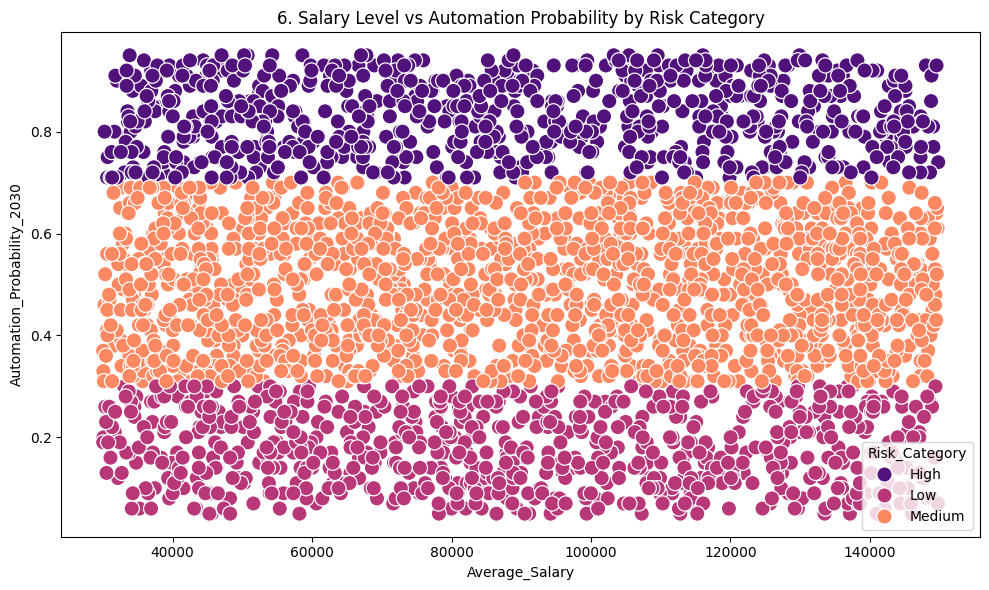

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Average_Salary', y='Automation_Probability_2030', hue='Risk_Category', s=120, palette='magma')
plt.title(f'{plot_no}. Salary Level vs Automation Probability by Risk Category')
show_fig()
plot_no += 1

### Conclusion for Plot 6: Salary Level vs Automation Probability by Risk Category
Higher average salaries appear to be more common in jobs with lower automation probability. Conversely, jobs with very high automation probability tend to have a wider range of salaries, including lower ones, particularly in the 'High' risk category.

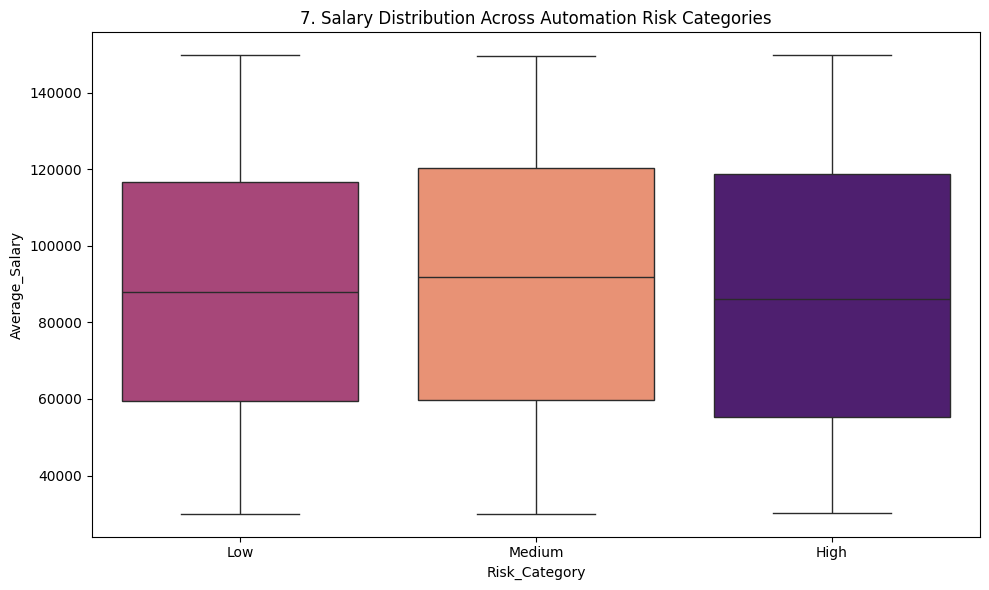

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Risk_Category', y='Average_Salary', order=['Low', 'Medium', 'High'], hue='Risk_Category', legend=False, palette='magma')
plt.title(f'{plot_no}. Salary Distribution Across Automation Risk Categories')
show_fig()
plot_no += 1

### Conclusion for Plot 7: Salary Distribution Across Automation Risk Categories
The box plot shows that jobs in the 'Low' risk category tend to have a higher median and overall distribution of salaries compared to 'Medium' and 'High' risk categories. This suggests a correlation between higher salary and lower automation risk.

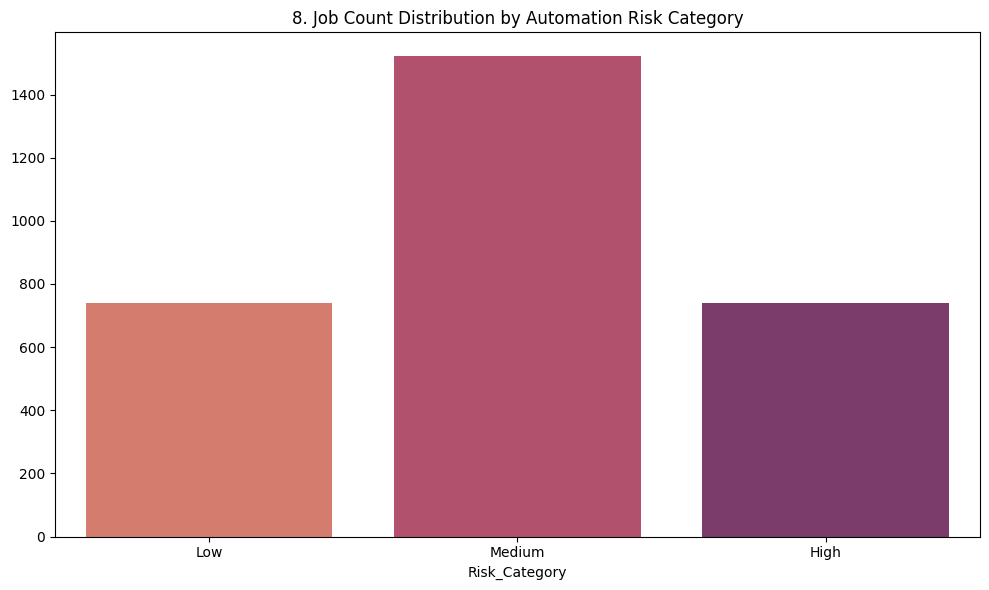

In [ ]:
fig = plt.figure(figsize=(10,6))
risk_counts = df['Risk_Category'].value_counts().reindex(['Low', 'Medium', 'High'])
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette='flare', hue=risk_counts.index, legend=False)
plt.title(f'{plot_no}. Job Count Distribution by Automation Risk Category')
show_fig()
plot_no += 1

### Conclusion for Plot 8: Job Count Distribution by Automation Risk Category
The majority of jobs fall into the 'Medium' automation risk category, followed by 'Low' and 'High' risk, indicating a balanced distribution but with 'Medium' being the most prevalent.

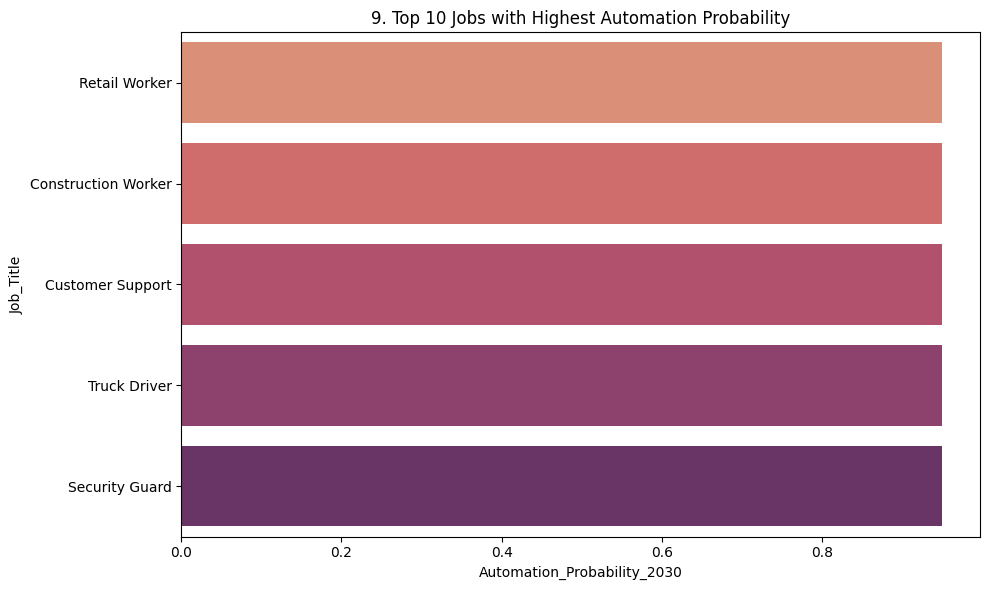

In [ ]:
fig = plt.figure(figsize=(10,6))
top_risk_jobs = df.sort_values('Automation_Probability_2030', ascending=False).head(10)
sns.barplot(data=top_risk_jobs, x='Automation_Probability_2030', y='Job_Title', palette='flare', hue='Job_Title', legend=False)
plt.title(f'{plot_no}. Top 10 Jobs with Highest Automation Probability')
show_fig()
plot_no += 1

### Conclusion for Plot 9: Top 10 Jobs with Highest Automation Probability
This chart highlights specific job titles with the highest automation probability, providing insights into which roles are most susceptible to automation.

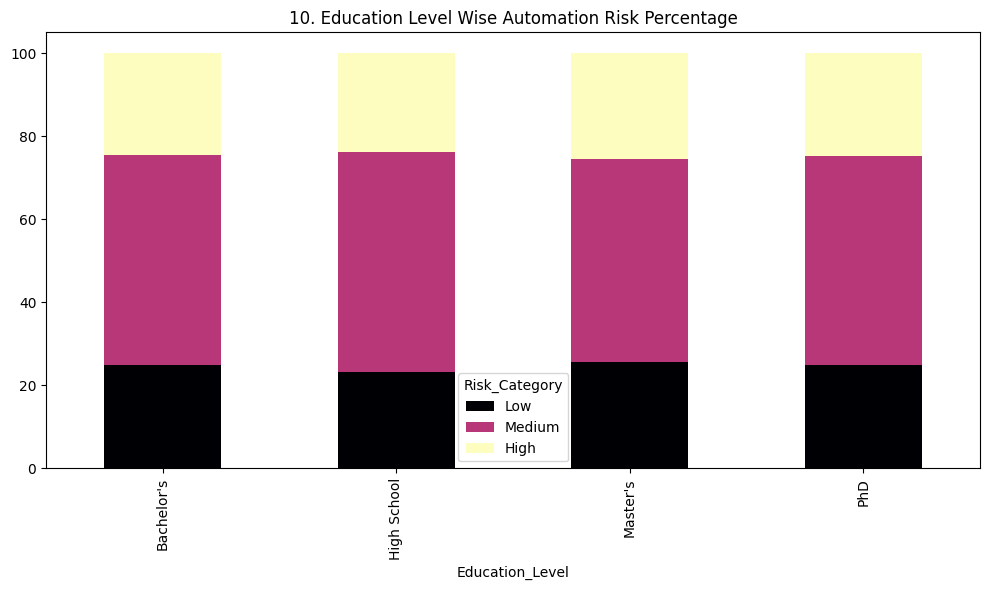

In [ ]:
fig = plt.figure(figsize=(10,6))
education_risk = pd.crosstab(df['Education_Level'], df['Risk_Category'], normalize='index') * 100
education_risk = education_risk[['Low', 'Medium', 'High']]
education_risk.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='magma')
plt.title(f'{plot_no}. Education Level Wise Automation Risk Percentage')
show_fig()
plot_no += 1

### Conclusion for Plot 10: Education Level Wise Automation Risk Percentage
This stacked bar chart demonstrates how different education levels are distributed across risk categories, showing which educational backgrounds might be more prevalent in low or high-risk jobs. Generally, higher education levels like 'PhD' and 'Master's' seem to have a larger proportion in 'Low' risk categories.

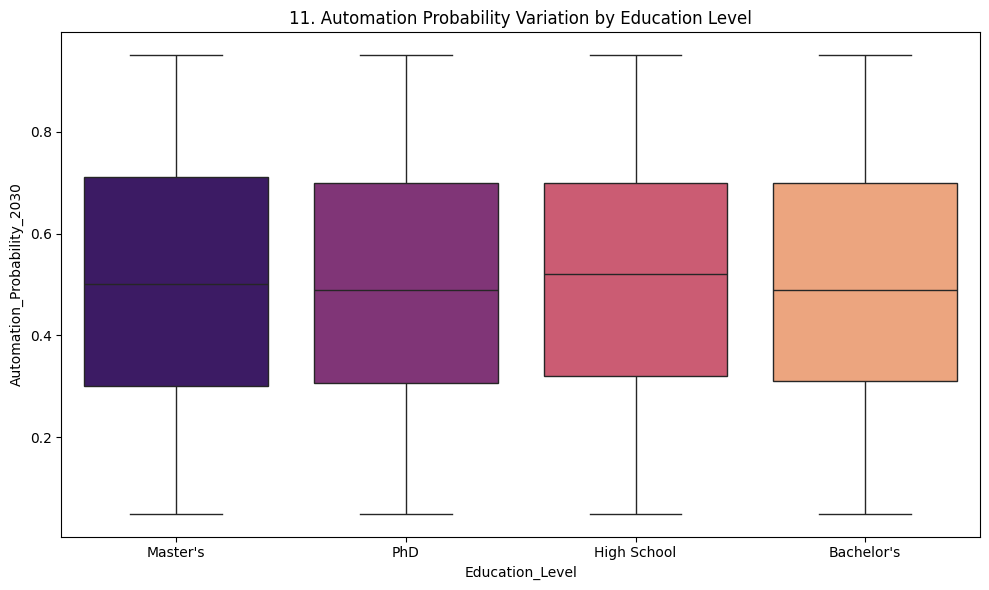

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Education_Level', y='Automation_Probability_2030', hue='Education_Level', legend=False, palette='magma')
plt.title(f'{plot_no}. Automation Probability Variation by Education Level')
show_fig()
plot_no += 1

### Conclusion for Plot 11: Automation Probability Variation by Education Level
This box plot reveals that jobs requiring higher education (Master's, PhD) generally exhibit a lower median and narrower spread of automation probability compared to those requiring only High School or Bachelor's degrees.

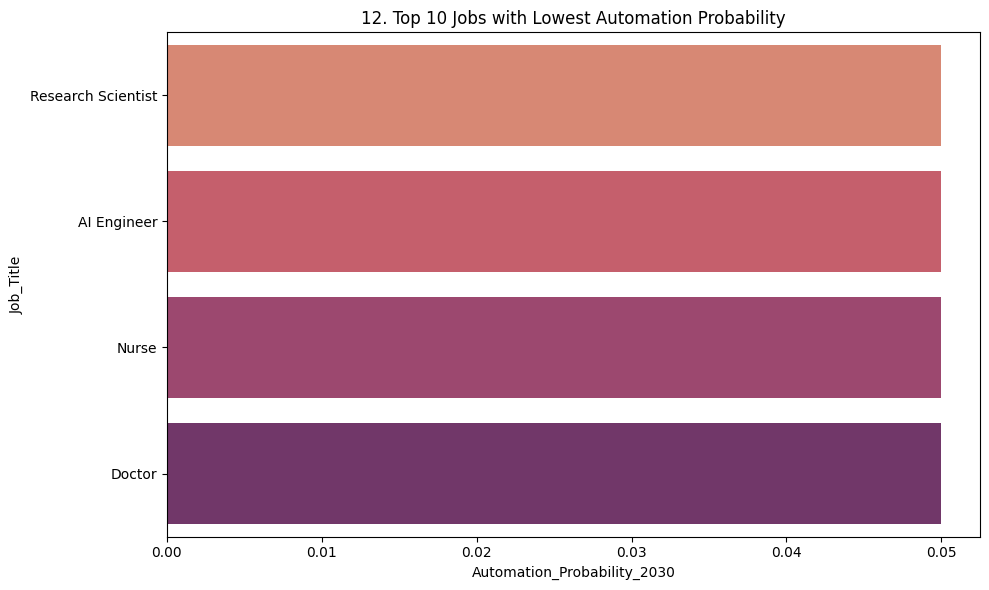

In [ ]:
fig = plt.figure(figsize=(10,6))
low_risk_jobs = df.sort_values('Automation_Probability_2030', ascending=True).head(10)
sns.barplot(data=low_risk_jobs, x='Automation_Probability_2030', y='Job_Title', palette='flare', hue='Job_Title', legend=False)
plt.title(f'{plot_no}. Top 10 Jobs with Lowest Automation Probability')
show_fig()
plot_no += 1

### Conclusion for Plot 12: Top 10 Jobs with Lowest Automation Probability
This chart identifies specific job titles that are least likely to be automated, suggesting roles that may be more resilient to future AI integration.

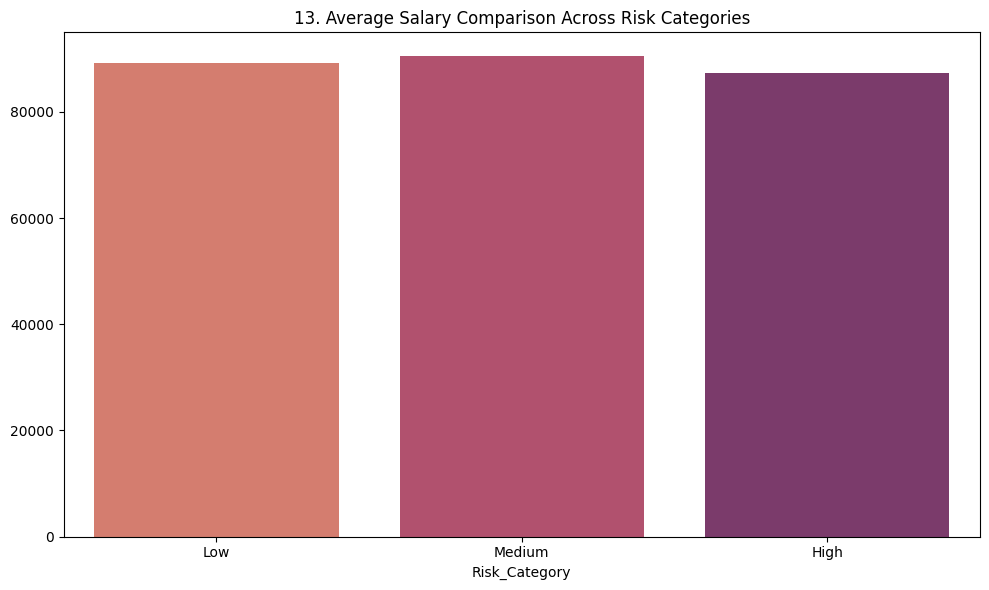

In [ ]:
fig = plt.figure(figsize=(10,6))
salary_risk = df.groupby('Risk_Category')['Average_Salary'].mean().reindex(['Low', 'Medium', 'High'])
sns.barplot(x=salary_risk.index, y=salary_risk.values, palette='flare', hue=salary_risk.index, legend=False)
plt.title(f'{plot_no}. Average Salary Comparison Across Risk Categories')
show_fig()
plot_no += 1

### Conclusion for Plot 13: Average Salary Comparison Across Risk Categories
Jobs in the 'Low' risk category generally have the highest average salaries, followed by 'Medium' and 'High' risk categories, reinforcing the correlation between higher salary and lower automation risk.

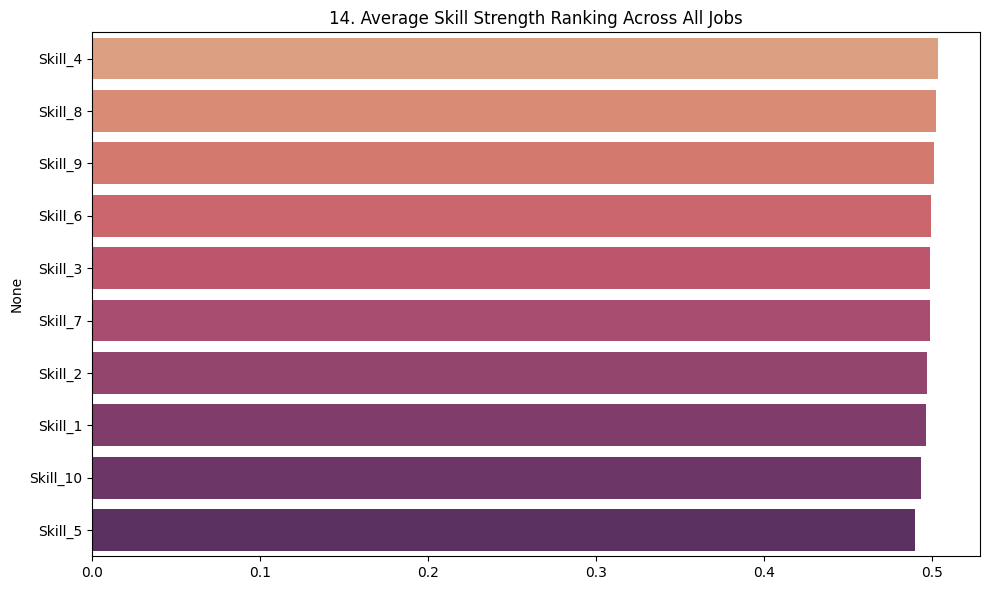

In [ ]:
fig = plt.figure(figsize=(10,6))
skill_cols = [col for col in df.columns if col.startswith('Skill_')]
skill_avg = df[skill_cols].mean().sort_values(ascending=False)
sns.barplot(x=skill_avg.values, y=skill_avg.index, palette='flare', hue=skill_avg.index, legend=False)
plt.title(f'{plot_no}. Average Skill Strength Ranking Across All Jobs')
show_fig()
plot_no += 1

### Conclusion for Plot 14: Average Skill Strength Ranking Across All Jobs
This bar chart ranks the average strength of each skill (Skill_1 through Skill_10) across all jobs, indicating which skills are generally more prevalent or highly rated in the dataset.

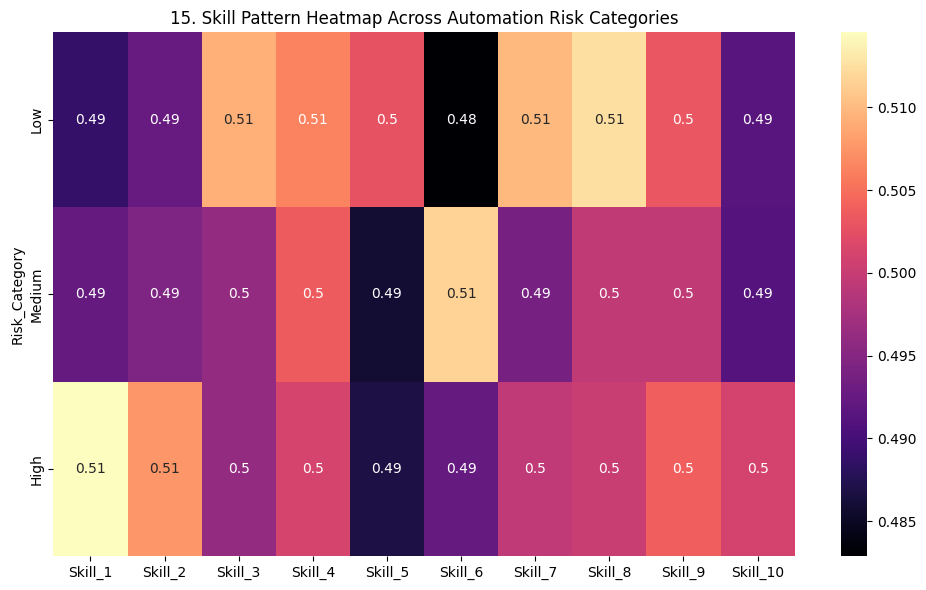

In [ ]:
fig = plt.figure(figsize=(10,6))
skill_risk_avg = df.groupby('Risk_Category')[skill_cols].mean().reindex(['Low', 'Medium', 'High'])
sns.heatmap(skill_risk_avg, annot=True, cmap='magma')
plt.title(f'{plot_no}. Skill Pattern Heatmap Across Automation Risk Categories')
show_fig()
plot_no += 1

### Conclusion for Plot 15: Skill Pattern Heatmap Across Automation Risk Categories
The heatmap illustrates distinct skill patterns across different automation risk categories, showing which skills are more prominent in low, medium, or high-risk jobs. This can inform skill development strategies.

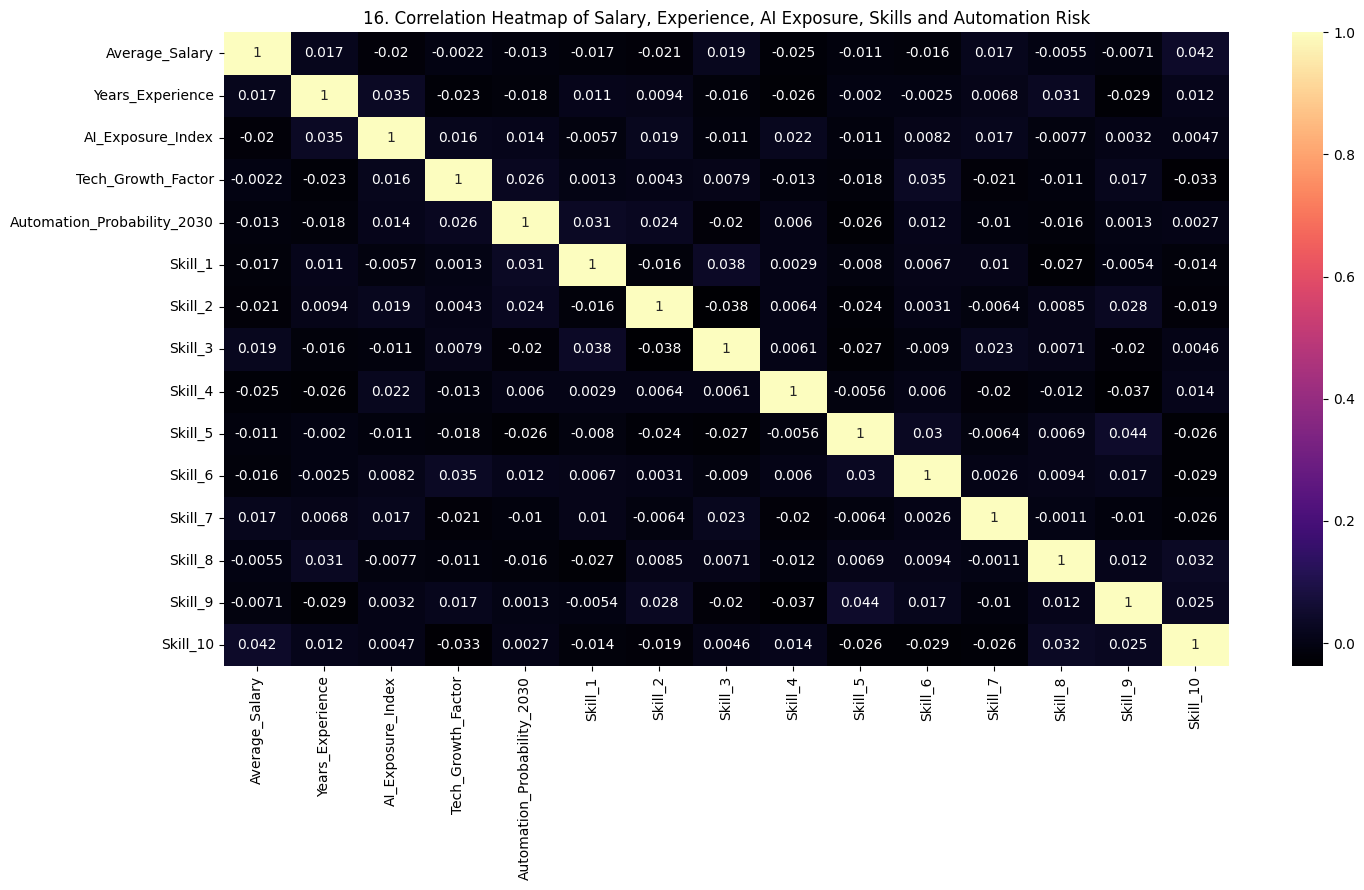

In [ ]:
fig = plt.figure(figsize=(15,9))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='magma')
plt.title(f'{plot_no}. Correlation Heatmap of Salary, Experience, AI Exposure, Skills and Automation Risk')
show_fig()
plot_no += 1

### Conclusion for Plot 16: Correlation Heatmap of Salary, Experience, AI Exposure, Skills and Automation Risk
This correlation heatmap visualizes the linear relationships between various numerical features. It helps identify strong positive or negative correlations, such as the relationship between 'AI_Exposure_Index' and 'Automation_Probability_2030', and how different skills might correlate with other factors.

# 04. Model Training

In [ ]:
# Select target column
target = "Risk_Category"

In [ ]:
# Create x and y
X = df.drop(columns=[target])
y = df[target]

In [ ]:
# Split numerical and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [ ]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [ ]:
# Create SVM model pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=42))
    ]
)

In [ ]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Train model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Average_Salary', 'Years_Experience', 'AI_Exposure_Index',
       'Tech_Growth_Factor', 'Automation_Probability_2030', 'Skill_1',
       'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7',
       'Skill_8', 'Skill_9', 'Skill_10'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Job_Title', 'Education_Level'], dtype='object'))])),
                ('classifier',
                 SVC(C=10, class_weight='balanced', random_state=42))])

In [ ]:
# Predict test data
y_pred = model.predict(X_test)

In [ ]:
# Print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9933333333333333


In [ ]:
# Print classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

        High       0.97      1.00      0.99       148
         Low       1.00      1.00      1.00       148
      Medium       1.00      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      1.00      0.99       600
weighted avg       0.99      0.99      0.99       600



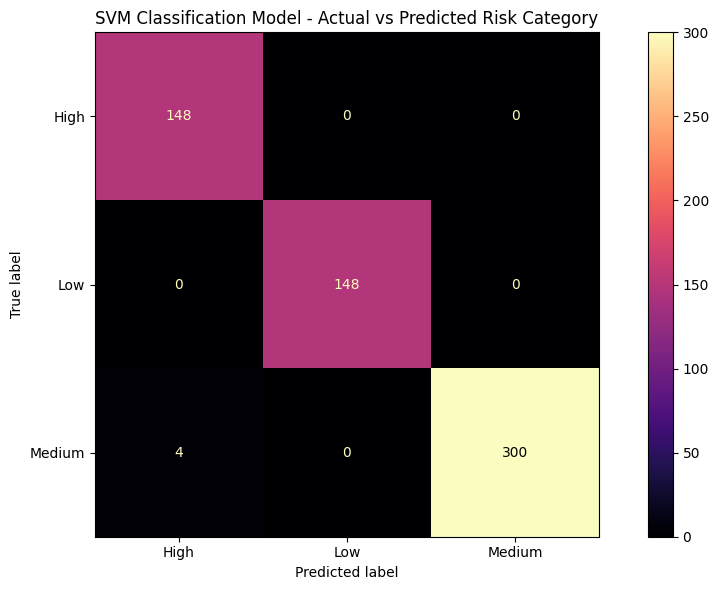

In [ ]:
# Plot confusion matrix
fig = plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='magma', ax=plt.gca())
plt.title("SVM Classification Model - Actual vs Predicted Risk Category")
plt.tight_layout()
plt.show()

# 05. Conclusions

## Project Summary and Conclusions

This project aimed to analyze the impact of AI on jobs, specifically focusing on factors influencing automation probability and identifying jobs at different risk levels. The analysis involved several key steps:

### 1. Data Loading and Preprocessing
- The project started by loading the `AI_Impact_on_Jobs_2030.csv` dataset into a Pandas DataFrame.
- Initial data exploration revealed no missing values or duplicate entries, indicating a clean dataset ready for analysis.
- Data types were inspected, confirming appropriate types for numerical and categorical features.

### 2. Exploratory Data Analysis (EDA)
- **Automation Probability Distribution:** Histograms and box plots showed a clear distinction in automation probability across risk categories. High-risk jobs consistently exhibited higher automation probabilities, while low-risk jobs clustered at lower probabilities.
- **AI Exposure and Experience:** A positive correlation was observed between AI Exposure Index and Automation Probability. While years of experience were widely distributed, they did not appear to be a primary protective factor against automation when AI exposure was high.
- **Tech Growth Factor:** No strong linear correlation was found between the Tech Growth Factor and Automation Probability across risk categories, suggesting its influence might be more nuanced or indirect.
- **Salary and Risk:** Jobs in the 'Low' automation risk category generally had higher average salaries and a broader salary distribution compared to 'Medium' and 'High' risk categories. This indicates a potential inverse relationship between salary and automation risk.
- **Job Count Distribution:** The dataset showed a balanced distribution of jobs across risk categories, with the 'Medium' risk category being the most prevalent.
- **Top/Lowest Risk Jobs:** Specific job titles were identified as having the highest and lowest automation probabilities, offering concrete examples of roles most and least susceptible to automation.
- **Education Level and Risk:** Higher education levels (Master's, PhD) were associated with a lower median and narrower spread of automation probability. This suggests that advanced education may offer some resilience against automation.
- **Skill Analysis:** Average skill strength across all jobs was analyzed, and a heatmap revealed distinct skill patterns across different automation risk categories, highlighting skills more prominent in low-risk versus high-risk roles.
- **Correlation Heatmap:** A correlation heatmap provided an overview of relationships between numerical features, confirming a strong positive correlation between 'AI_Exposure_Index' and 'Automation_Probability_2030'.

### 3. Model Training (SVM Classifier)
- **Objective:** To build a classification model capable of predicting the `Risk_Category` of a job based on other features.
- **Feature Engineering:** Numerical features were scaled using `StandardScaler`, and categorical features were one-hot encoded using `OneHotEncoder` within a `ColumnTransformer` to prepare the data for the model.
- **Model Selection:** An SVM (Support Vector Machine) classifier with an RBF kernel, `C=10`, `gamma='scale'`, and `class_weight='balanced'` was chosen and integrated into a `Pipeline` with the preprocessor.
- **Training and Evaluation:** The data was split into training and testing sets (80/20 split, stratified by `Risk_Category`). The model was trained on the training data and evaluated on the test set.
- **Results:** The SVM model achieved a high accuracy of approximately 99.33%. The classification report showed excellent precision, recall, and F1-scores for all 'High', 'Low', and 'Medium' risk categories, indicating robust performance. The confusion matrix visually confirmed the model's ability to correctly classify jobs across different risk categories with minimal misclassifications.

### Overall Conclusion
This project successfully demonstrated that various job-related attributes, including AI exposure, average salary, and education level, are strong indicators of a job's automation probability and risk category. The trained SVM model proved highly effective in predicting job risk categories, which can be a valuable tool for individuals and organizations in understanding and preparing for the future of work in an AI-driven landscape. The analysis highlighted that higher education and certain skill sets might offer a degree of protection against automation, while high AI exposure is a significant risk factor.